## Задание 1. Создание нейросети в Scikit learn

Используя возможности библиотеки scikit learn разработайте простую нейронную сеть (многослойный персептрон), используя один из датасетов предложенных преподавателем или собственный датасет. При реализации задания необходимо выполнить следующие этапы:
подготовка обучающих данных;
создание нейросети;
подбор гиперпараметров с помощью GridSearchCV или RandomizedSearchCV;
обучение нейросети;
визуализация результатов и подсчет метрик качества.
*Примечание: для выполнения задания можно использовать возможности библиотек, изученных ранее (numpy, pandas, Matplotlib, seaborn).*

### Решение задания 1

Ниже реализована нейронная сеть средствами `scikit-learn`: подготовка данных, создание `MLPClassifier`, подбор гиперпараметров через `GridSearchCV`, обучение, визуализация и метрики качества. Работа выполнена по API `sklearn`: `fit()`, `predict()`, `train_test_split`, метрики и матрица ошибок.

Размер матрицы признаков X: (569, 30)
Размер целевого вектора y: (569,)
Классы: {0: np.str_('malignant'), 1: np.str_('benign')}
Лучшие гиперпараметры: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (20,), 'mlp__learning_rate_init': 0.01}
Лучший средний F1 на кросс-валидации: 0.9733


,metric,value
0,accuracy,0.958042
1,precision,0.988372
2,recall,0.944444
3,f1,0.965909


              precision    recall  f1-score   support

   malignant       0.91      0.98      0.95        53
      benign       0.99      0.94      0.97        90

    accuracy                           0.96       143
   macro avg       0.95      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



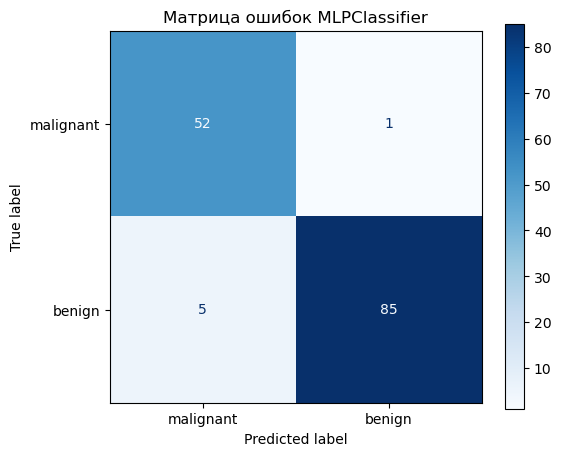

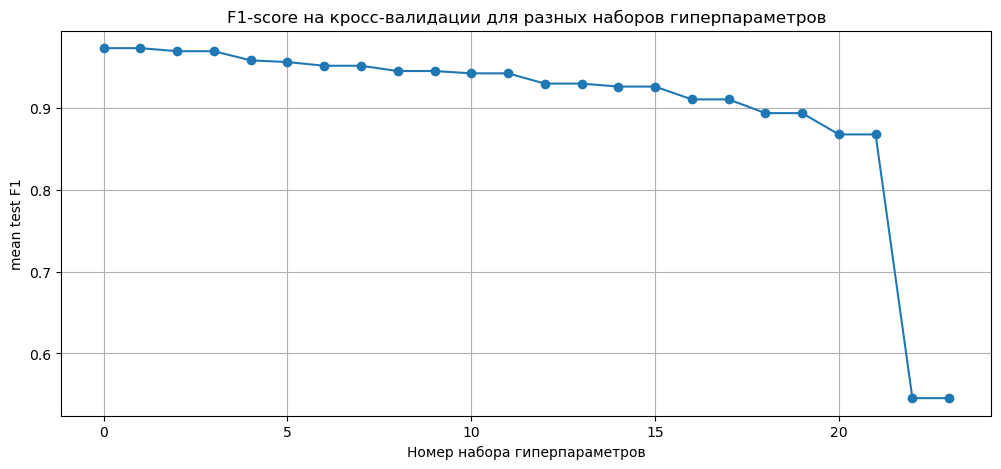

,mean_test_score,std_test_score,params
15,0.973324,0.017798,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.00..."
21,0.973324,0.017798,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.00..."
3,0.969584,0.016694,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00..."
9,0.969584,0.016694,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00..."
11,0.958368,0.010662,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00..."
5,0.956310,0.010985,"{'mlp__activation': 'relu', 'mlp__alpha': 0.00..."
23,0.951787,0.012375,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.00..."
17,0.951787,0.012375,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.00..."
16,0.945334,0.010853,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.00..."
22,0.945334,0.010853,"{'mlp__activation': 'tanh', 'mlp__alpha': 0.00..."


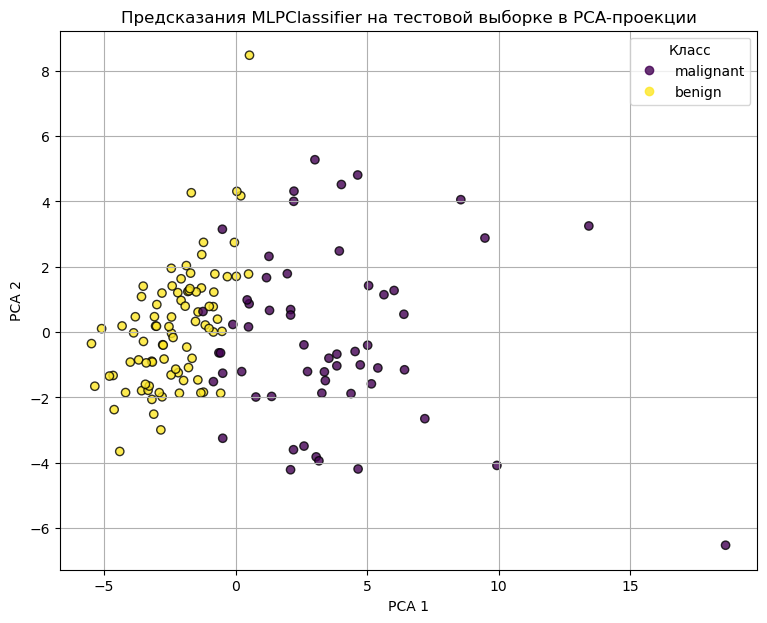

In [19]:
# Задание 1. Многослойный персептрон в scikit-learn
# Используем встроенный датасет breast_cancer: это готовая бинарная задача классификации.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42

# 1) Подготовка обучающих данных: X -- матрица признаков, y -- целевой вектор.
breast_cancer = load_breast_cancer(as_frame=True)
X_bc = breast_cancer.data
y_bc = breast_cancer.target

print('Размер матрицы признаков X:', X_bc.shape)
print('Размер целевого вектора y:', y_bc.shape)
print('Классы:', dict(enumerate(breast_cancer.target_names)))

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc,
    y_bc,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_bc,
)

# 2) Создание нейросети. StandardScaler важен для MLP, потому что признаки имеют разные масштабы.
mlp_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(max_iter=1000, random_state=RANDOM_SEED, early_stopping=True)),
    ]
)

# 3) Подбор гиперпараметров через GridSearchCV.
param_grid = {
    'mlp__hidden_layer_sizes': [(10,), (20,), (20, 10)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate_init': [0.001, 0.01],
}

grid_mlp = GridSearchCV(
    estimator=mlp_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=1,
    return_train_score=True,
)

# 4) Обучение нейросети.
grid_mlp.fit(X_train_bc, y_train_bc)
best_mlp = grid_mlp.best_estimator_
y_pred_bc = best_mlp.predict(X_test_bc)

print('Лучшие гиперпараметры:', grid_mlp.best_params_)
print('Лучший средний F1 на кросс-валидации:', round(grid_mlp.best_score_, 4))

# 5) Метрики качества.
metrics_table = pd.DataFrame(
    {
        'metric': ['accuracy', 'precision', 'recall', 'f1'],
        'value': [
            accuracy_score(y_test_bc, y_pred_bc),
            precision_score(y_test_bc, y_pred_bc),
            recall_score(y_test_bc, y_pred_bc),
            f1_score(y_test_bc, y_pred_bc),
        ],
    }
)
display(metrics_table)

print(classification_report(y_test_bc, y_pred_bc, target_names=breast_cancer.target_names))

# Визуализация 1: матрица ошибок.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_bc,
    y_pred_bc,
    display_labels=breast_cancer.target_names,
    cmap='Blues',
    ax=ax,
)
plt.title('Матрица ошибок MLPClassifier')
plt.show()

# Визуализация 2: качество моделей из сетки параметров.
cv_results = pd.DataFrame(grid_mlp.cv_results_).sort_values('mean_test_score', ascending=False)
plt.figure(figsize=(12, 5))
plt.plot(range(len(cv_results)), cv_results['mean_test_score'].values, marker='o')
plt.title('F1-score на кросс-валидации для разных наборов гиперпараметров')
plt.xlabel('Номер набора гиперпараметров')
plt.ylabel('mean test F1')
plt.grid(True)
plt.show()

display(cv_results[['mean_test_score', 'std_test_score', 'params']].head(10))

# Визуализация 3: проекция тестовых объектов в 2D через PCA и предсказанные классы.
X_test_scaled_bc = best_mlp.named_steps['scaler'].transform(X_test_bc)
X_test_2d_bc = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X_test_scaled_bc)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_test_2d_bc[:, 0],
    X_test_2d_bc[:, 1],
    c=y_pred_bc,
    cmap='viridis',
    edgecolor='k',
    alpha=0.8,
)
plt.title('Предсказания MLPClassifier на тестовой выборке в PCA-проекции')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(handles=scatter.legend_elements()[0], labels=list(breast_cancer.target_names), title='Класс')
plt.grid(True)
plt.show()


## Задание 2. Алгоритм обратного распространения ошибки

---

В данном задании Вам нужно будет:
- дополнить класс **`Neuron()`** с функцией активации ReLU, чтобы в нём было запрограмировано обучение нейронной сети по методу обратного распространения ошибки (прямой и обратный проход по сети)

- обучить и протестировать этот класс на сгенерированных и реальных данных

In [20]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd

In [21]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---

В данном случае мы решаем задачу бинарной классификации (2 класса: 1 или 0). Для простоты в качестве функции потерь возьмём квадратичную функцию потерь, хоть она и плохо показывает себя в задаче классификации.

$$
Loss(\hat{y}, y) = \frac{1}{n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2
$$  

Здесь $w \cdot X_i$ - скалярное произведение, а $\hat{y_i} = \sigma(w \cdot X_i ), а \  \sigma$- функция активации ($i$ -- номер объекта в выборке).

In [22]:
def Loss(y_pred, y):
    y_pred = y_pred.reshape(-1, 1)
    y = np.array(y).reshape(-1, 1)
    return 0.5 * np.mean((y_pred - y) ** 2)

<h2 style="text-align: center;"><b>Нейрон с ReLU (Recitified Linear Unit)</b></h2>  

ReLU самая часто используемая (по крайней мере, пару лет назад) функция активации в нейронных сетях. Выглядит она очень просто:

\begin{equation*}
ReLU(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Или по-другому:

$$
ReLU(x) = \max(0, x)
$$

В (свободном) переводе Rectified Linear Unit = "Усечённая линейная функция". Собственно, мы по сути просто не даём проходить отрицательным числам.

Производная здесь берётся как производная от кусочно-заданной функции, то есть на участках, где функция гладкая, и в нуле её доопредляют нулём:

\begin{equation*}
ReLU'(x) =
 \begin{cases}
   0, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим ReLu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ReLU(w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
    y_i^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

(помните, что $w \cdot X_i$ -- это число в данном случае (результат скалярного произведения двух векторов)).

Тогда формула для обновления весов при градиентном спуске будет такая (в матричном виде, рекмендуем вывести самим то, как это получается из формулы для одного объекта):

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   0, &{w \cdot X_i \le 0}\\
   \frac{1}{n} X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

(напоминаем, что здесь $w \cdot X$ -- матричное произведение вектора $w$ (ведь вектор -- тоже матрица, не так ли?) и матрицы $X$ )

Почему в первом случае будет 0? Потому что в формулу $y_i^2$ не входят веса , а мы берём производную именно по весам $w$.

* Реализуйте ReLU и её производную:

In [23]:
def relu(x):
    """ReLU-функция: max(0, x)."""
    return np.maximum(0, x)

In [24]:
def relu_derivative(x):
    """Производная ReLU: 0 при x <= 0 и 1 при x > 0."""
    x = np.asarray(x)
    return (x > 0).astype(float)

Теперь нужно написать класс нейрон с ReLU:

In [25]:
class NeuronReLU:
    def __init__(self, w=None, b=0):
        """
        :param: w -- вектор весов размера (m, 1)
        :param: b -- смещение
        """
        self.w = w
        self.b = b

    def activate(self, x):
        return relu(x)

    def forward_pass(self, X):
        """
        Рассчитывает ответ нейрона при предъявлении набора объектов.
        :param: X -- матрица примеров размера (n, m), каждая строка - отдельный объект
        :return: вектор размера (n, 1) с ответами нейрона
        """
        X = np.asarray(X, dtype=float)
        if self.w is None:
            raise ValueError('Сначала задайте веса self.w или вызовите fit().')
        self.w = np.asarray(self.w, dtype=float).reshape(X.shape[1], 1)
        z = X @ self.w + self.b
        y_pred = self.activate(z)
        return y_pred.reshape(-1, 1)

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        """
        Обновляет веса и смещение методом градиентного спуска.
        Для Loss = 1/(2n) * sum((y_pred - y)^2):
        dLoss/dz = (y_pred - y) * ReLU'(z), где z = X @ w + b.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1, 1)
        y_pred = np.asarray(y_pred, dtype=float).reshape(-1, 1)
        n = len(y)

        z = X @ self.w + self.b
        dZ = (y_pred - y) * relu_derivative(z)
        grad_w = (X.T @ dZ) / n
        grad_b = np.mean(dZ)

        self.w -= learning_rate * grad_w
        self.b -= learning_rate * grad_b

    def fit(self, X, y, num_epochs=300, learning_rate=0.005, random_state=RANDOM_SEED):
        """
        Спускаемся в минимум.
        :param: X -- матрица объектов размера (n, m)
        :param: y -- вектор правильных ответов размера (n, 1)
        :param: num_epochs -- количество итераций обучения
        :return: Loss_values -- список значений функции потерь
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1, 1)

        # Важный момент для ReLU: не обнуляем веса, если они уже заданы.
        # Если веса не переданы, инициализируем их малыми случайными числами.
        if self.w is None:
            rng = np.random.RandomState(random_state)
            self.w = rng.normal(loc=0.0, scale=0.01, size=(X.shape[1], 1))
        else:
            self.w = np.asarray(self.w, dtype=float).reshape(X.shape[1], 1)
        self.b = float(np.asarray(self.b).ravel()[0])

        Loss_values = []
        for _ in range(num_epochs):
            y_pred = self.forward_pass(X)
            Loss_values.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred, learning_rate=learning_rate)

        return Loss_values

<h3 style="text-align: center;"><b>Тестирование нейрона с ReLU</b></h3>  

Здесь Вам нужно самим протестировать новый нейрон **на данных** ("Яблоки и Груши").
В итоге нужно вывести:
* график, на котором будет показано, как изменяется функция потерь $Loss$ в зависимости от числа итераций обучения
* график с раскраской выборки нейроном

***ПРИМЕЧАНИЕ***: пожалуйста, почаще проверяйте `.shape` у матриц и векторов: `self.w`, `X` и `y` внутри класса. Очень часто ошибка решается транспонированием или `.reshape()`'ом. Не забывайте проверять, что на что Вы умножаете и какой вектор (какой размер) хотите получить на выходе -- это очень помогает не запутаться.

** Проверка forward_pass()**

In [26]:
w = np.array([1., 2.]).reshape(2, 1)
b = 2.
X = np.array([[1., 3.],
              [2., 4.],
              [-1., -3.2]])

neuron = NeuronReLU(w, b)
y_pred = neuron.forward_pass(X)
print ("y_pred = " + str(y_pred))

y_pred = [[ 9.]
 [12.]
 [ 0.]]


*Hint: "**-0.**" -- это просто ноль*

**Проверка backward_pass()**

In [27]:
y = np.array([1, 0, 1]).reshape(3, 1)

In [28]:
neuron.backward_pass(X, y, y_pred)

print ("w = " + str(neuron.w))
print ("b = " + str(neuron.b))

w = [[0.94666667]
 [1.88      ]]
b = 1.9666666666666666


"Яблоки и Груши" (необходимо положить данные в папку `./data`):

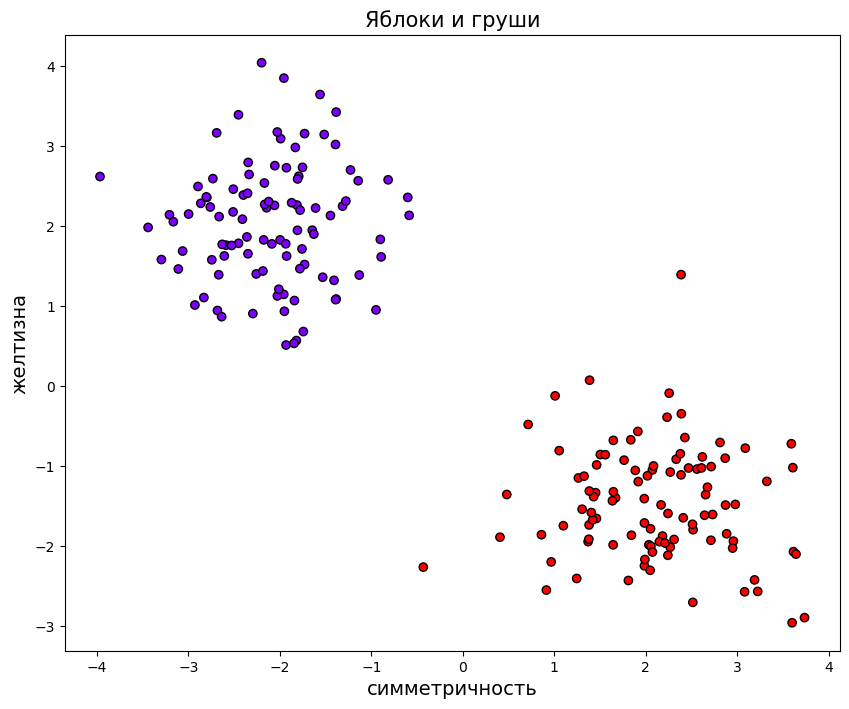

In [29]:
from pathlib import Path
from sklearn.datasets import make_blobs

# Если файл с яблоками и грушами уже есть в ./data, используем его.
# Если файла нет, создаем учебный линейно-разделимый датасет с теми же признаками.
data_path = Path('./data/apples_pears.csv')
data_path.parent.mkdir(exist_ok=True)

if not data_path.exists():
    X_generated, y_generated = make_blobs(
        n_samples=200,
        centers=np.array([[-2.0, 2.0], [2.0, -1.5]]),
        cluster_std=0.75,
        random_state=RANDOM_SEED,
    )
    generated_data = pd.DataFrame(X_generated, columns=['symmetry', 'yellowness'])
    generated_data['target'] = y_generated
    generated_data.to_csv(data_path, index=False)

data = pd.read_csv(data_path)

plt.figure(figsize=(10, 8))
plt.scatter(data.iloc[:, 0], data.iloc[:, 1], c=data['target'], cmap='rainbow', edgecolor='k')
plt.title('Яблоки и груши', fontsize=15)
plt.xlabel('симметричность', fontsize=14)
plt.ylabel('желтизна', fontsize=14)
plt.show();

In [30]:
X = data.iloc[:,:2].values  # матрица объекты-признаки
y = data['target'].values.reshape((-1, 1))  # классы (столбец из нулей и единиц)

Выведите лосс при обучении нейрона с ReLU на этом датасете:

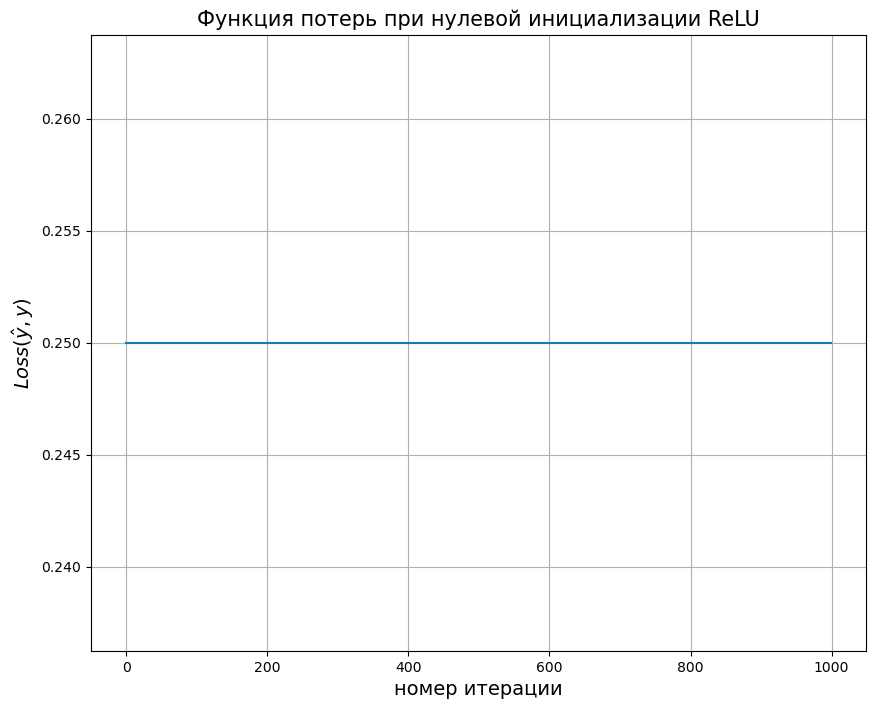

Начальный/конечный loss: 0.25 0.25
CPU times: total: 250 ms
Wall time: 253 ms


In [31]:
%%time

# Демонстрация проблемы ReLU при нулевой инициализации: z = 0, ReLU'(0) = 0,
# поэтому градиент равен нулю и веса не обновляются.
neuron_zero = NeuronReLU(w=np.zeros((X.shape[1], 1)), b=0)
Loss_values_zero = neuron_zero.fit(X, y, num_epochs=1000)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values_zero)
plt.title('Функция потерь при нулевой инициализации ReLU', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\\hat{y}, y)$', fontsize=14)
plt.grid(True)
plt.show()

print('Начальный/конечный loss:', Loss_values_zero[0], Loss_values_zero[-1])

Скорее всего сейчас у вас лосс -- это прямая линия, и вы видите, что веса не обновляются. Но почему?

Всё просто -- если присмотреться, то видно, что self.w и self.b иницилизируются нулями в начале `.fit()`-метода. Если расписать, как будет идти обновление, то видно, что из-за ReLU веса просто-напросто не будут обновляться, если начать с инициализации нулями.

Это -- одна из причин, по которой в нейронных сетях веса инициализируют случайными числами (обычно из отрезка [0, 1)).

Обучим нейрон, инициализировав случайно веса (поставьте 10000 итераций).

**!!! Закомментируйте инициализацию нулями в функции `.fit()` класса `NeuronReLU` !!!**

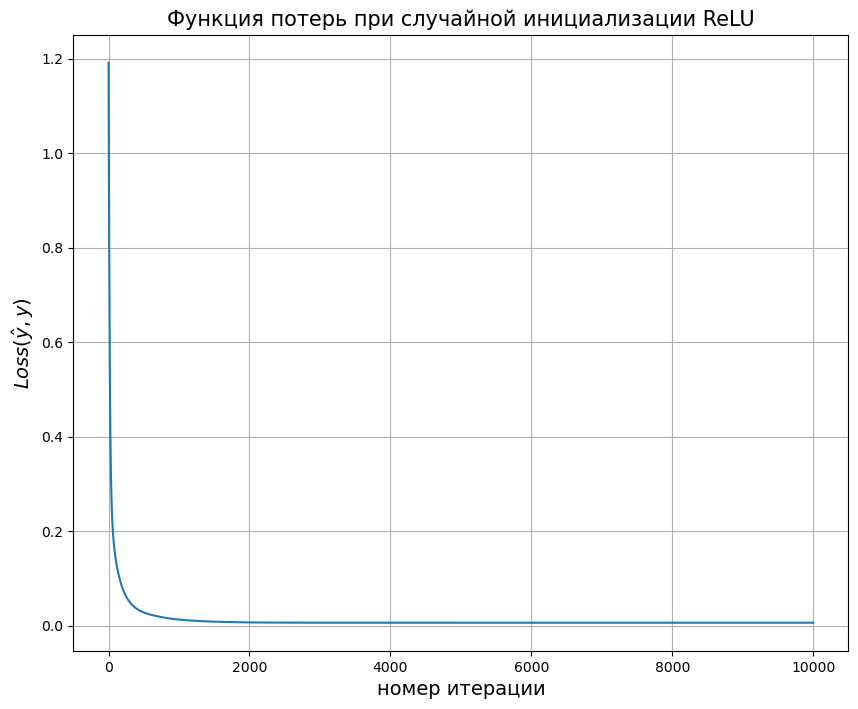

Начальный/конечный loss: 1.1910797916948168 0.006477947905207238
CPU times: total: 938 ms
Wall time: 940 ms


In [32]:
%%time

# Теперь используем случайную инициализацию весов -- так ReLU-нейрон начинает обучаться.
neuron = NeuronReLU(w=np.random.rand(X.shape[1], 1), b=np.random.rand(1))
Loss_values = neuron.fit(X, y, num_epochs=10000, learning_rate=0.005)

plt.figure(figsize=(10, 8))
plt.plot(Loss_values)
plt.title('Функция потерь при случайной инициализации ReLU', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\\hat{y}, y)$', fontsize=14)
plt.grid(True)
plt.show()

print('Начальный/конечный loss:', Loss_values[0], Loss_values[-1])

Посмотрим, как предсказывает этот нейрон:

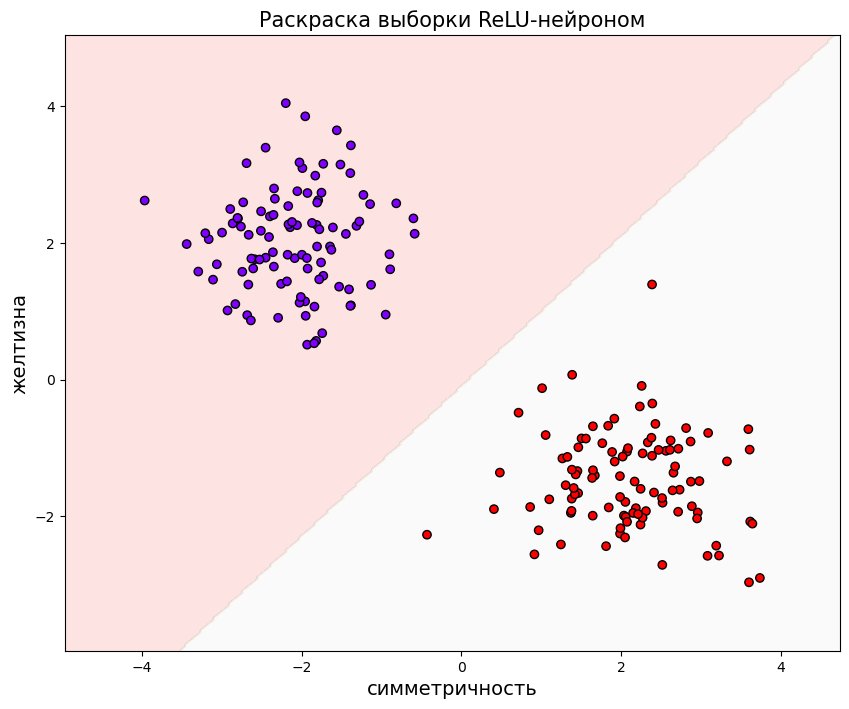

Accuracy ReLU-нейрона: 1.0


In [33]:
def plot_neuron_decision_regions(neuron, X, y, title, cmap_background='Pastel1', cmap_points='rainbow'):
    """Визуализация раскраски плоскости и исходной выборки нейроном."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y).ravel()

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    z = (neuron.forward_pass(grid) > 0.5).astype(int).reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, z, alpha=0.35, cmap=cmap_background)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolor='k')
    plt.title(title, fontsize=15)
    plt.xlabel('симметричность', fontsize=14)
    plt.ylabel('желтизна', fontsize=14)
    plt.show()

plot_neuron_decision_regions(neuron, X, y, 'Раскраска выборки ReLU-нейроном')

relu_pred = (neuron.forward_pass(X) > 0.5).astype(int).ravel()
print('Accuracy ReLU-нейрона:', np.mean(relu_pred == y.ravel()))

Есть одна тенденция: пороговая функция активации и сигмоида (обычно всё же только сигмоида) чаще используются именно на **выходном слое** нейросети в задаче классификации -- ими предсказывают вероятности объектов принадлежать одному из классов, в то время как продвинутые функции активации (ReLU и те, что будут дальше) используются внутри нейросети, то есть в **скрытых слоях**.

Нужно понимать, что ReLU не может вернуть отрицательные числа.

**Плюсы ReLU:**

* дифференцируемая (с доопределением в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде

**Возможные минусы ReLU:**

* не центрирована около 0 (может мешать скорости сходимости)
* зануляет все отрицательные входы, тем самым веса у занулённых нейронов могут часто *не обновляться*, эту проблему иногда называют *мёртвые нейроны*

С последней проблемой можно побороться, а именно:

<h2 style="text-align: center;"><b>Нейрон с LeakyReLU (Leaky Recitified Linear Unit)</b></h2>  

LeakyReLU очень слабо отличается от ReLU, но часто помогает сети обучаться быстрее, поскольку нет проблемы "мёртвых нейронов":

\begin{equation*}
LeakyReLU(x) =
 \begin{cases}
   \alpha x, &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
LeakyReLU'(x) =
 \begin{cases}
   \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Подставим LeakyReLu в Loss:

$$
Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (LeakyReLU(w \cdot X_i) - y_i)^2 =
\begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha \cdot w \cdot X_i - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}
$$  

Формула для обновления весов при градиентном спуске:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   \alpha X_i^T (w \cdot X_i - y), &{w \cdot X_i \le 0}\\
    X_i^T (w \cdot X_i - y), &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$


**Плюсы LeakyReLU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU

**Возможные минусы LeakyReLU:**

* не центрирована около 0 (может мешать скорости сходимсти)
* немного не устойчива к "шуму" (см. лекции Стэнфорда)

<h2 style="text-align: center;"><b>Нейрон с ELU (Exponential Linear Unit)</a></b></h2>  

ELU -- не так давно предложенная (в 2015 году) функция активации, которая, как говорят авторы статьи, лучше LeakyReLU. Вот формула ELU:

\begin{equation*}
ELU(\alpha, x) =
 \begin{cases}
   \alpha (e^x - 1), &\text{$x \le 0$}\\
   x, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

где $\alpha$ -- маленькое число от 0 до 1.

Производная здесь берётся так же, но вместо нуля будет $\alpha$:

\begin{equation*}
ELU'(x) =
 \begin{cases}
   ELU(\alpha, x) + \alpha, &\text{$x \le 0$}\\
   1, &\text{$x \gt 0$}
 \end{cases}
\end{equation*}

Здесь в производной использован постой трюк -- сделано $- \alpha + \alpha$, чтобы вычислять было проще.

График этой функции:

<img src="http://p0.ifengimg.com/pmop/2017/0907/A004001DD141881BFD8AD62E5D31028C3BE3FAD1_size14_w446_h354.png" width=500 height=400>

Подставим ELu в Loss:

$$Loss(\hat{y}, y) = \frac{1}{2n}\sum_{i=1}^{n} (\hat{y_i} - y_i)^2 = \frac{1}{2n}\sum_{i=1}^{n} (ELU(\alpha, w \cdot X_i) - y_i)^2 = \begin{equation*}
\frac{1}{2n}\sum_{i=1}^{n}
 \begin{cases}
   (\alpha (e^{w \cdot X_i} - 1) - y_i)^2, &{w \cdot X_i \le 0}\\
   (w \cdot X_i - y_i)^2, &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$  

Здесь вам нужно выписать самим град спуск для весов. Брать производную "в лоб" некрасиво и неудобно. Нужно воспользоваться **правилом цепочки**, оно же **правило взятия производной сложной функции**:

$$ \frac{\partial Loss}{\partial w} = \begin{equation*}
\frac{1}{n}\sum_{i=1}^{n}
 \begin{cases}
   , &{w \cdot X_i \le 0}\\
   , &{w \cdot X_i \gt 0}
 \end{cases}
\end{equation*}$$

**Плюсы ELU:**

* дифференцируемая (с доопределнием в нуле)
* нет проблемы затухающих градиентов, как в сигмоиде
* нет проблемы "мёртвых нейронов", как в ReLU
* более устойчива к "шуму" (см. лекции Стэнфорда)

**Возможные минусы ELU:**

* не очень хорошо центрирована около 0 (может мешать скорости сходимсти)
* вычислительно дольше, чем ReLU и LeakyReLU

---

И напоследок -- ещё интересные функции активации:

`SeLU()` и `Swish()`. Про них можно прочитать здесь: [SeLU](https://arxiv.org/pdf/1706.02515.pdf), [Swish](https://arxiv.org/pdf/1710.05941.pdf).

За функцию активации можно взять вообще почти любую функцию (которая, как вы полагаете, будет помогать обучению). Ещё больше функций активации вы можете [найти на википедии](https://en.wikipedia.org/wiki/Activation_function).

## Задание 3. Нейрон с различными функциями активации

Реализуйте предыдущее задание с помощью функций активации LeakyReLU и ELU. Сравните результаты

In [34]:
# Задание 3. Функции активации LeakyReLU и ELU.

def leaky_relu(x, alpha=0.01):
    """LeakyReLU: alpha * x при x <= 0 и x при x > 0."""
    return np.where(np.asarray(x) > 0, x, alpha * np.asarray(x))


def leaky_relu_derivative(x, alpha=0.01):
    """Производная LeakyReLU."""
    x = np.asarray(x)
    return np.where(x > 0, 1.0, alpha)


def elu(x, alpha=1.0):
    """ELU: alpha * (exp(x) - 1) при x <= 0 и x при x > 0."""
    x = np.asarray(x)
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))


def elu_derivative(x, alpha=1.0):
    """Производная ELU: 1 при x > 0 и alpha * exp(x) при x <= 0."""
    x = np.asarray(x)
    return np.where(x > 0, 1.0, alpha * np.exp(x))


class NeuronActivation:
    """Один нейрон с произвольной дифференцируемой функцией активации."""
    def __init__(self, activation, activation_derivative, w=None, b=0):
        self.activation = activation
        self.activation_derivative = activation_derivative
        self.w = w
        self.b = b

    def forward_pass(self, X):
        X = np.asarray(X, dtype=float)
        if self.w is None:
            raise ValueError('Сначала задайте веса self.w или вызовите fit().')
        self.w = np.asarray(self.w, dtype=float).reshape(X.shape[1], 1)
        z = X @ self.w + self.b
        return self.activation(z).reshape(-1, 1)

    def backward_pass(self, X, y, y_pred, learning_rate=0.005):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1, 1)
        y_pred = np.asarray(y_pred, dtype=float).reshape(-1, 1)
        n = len(y)

        z = X @ self.w + self.b
        dZ = (y_pred - y) * self.activation_derivative(z)
        grad_w = (X.T @ dZ) / n
        grad_b = np.mean(dZ)

        self.w -= learning_rate * grad_w
        self.b -= learning_rate * grad_b

    def fit(self, X, y, num_epochs=300, learning_rate=0.005, random_state=RANDOM_SEED):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1, 1)
        if self.w is None:
            rng = np.random.RandomState(random_state)
            self.w = rng.normal(loc=0.0, scale=0.01, size=(X.shape[1], 1))
        else:
            self.w = np.asarray(self.w, dtype=float).reshape(X.shape[1], 1)
        self.b = float(np.asarray(self.b).ravel()[0])

        Loss_values = []
        for _ in range(num_epochs):
            y_pred = self.forward_pass(X)
            Loss_values.append(Loss(y_pred, y))
            self.backward_pass(X, y, y_pred, learning_rate=learning_rate)
        return Loss_values

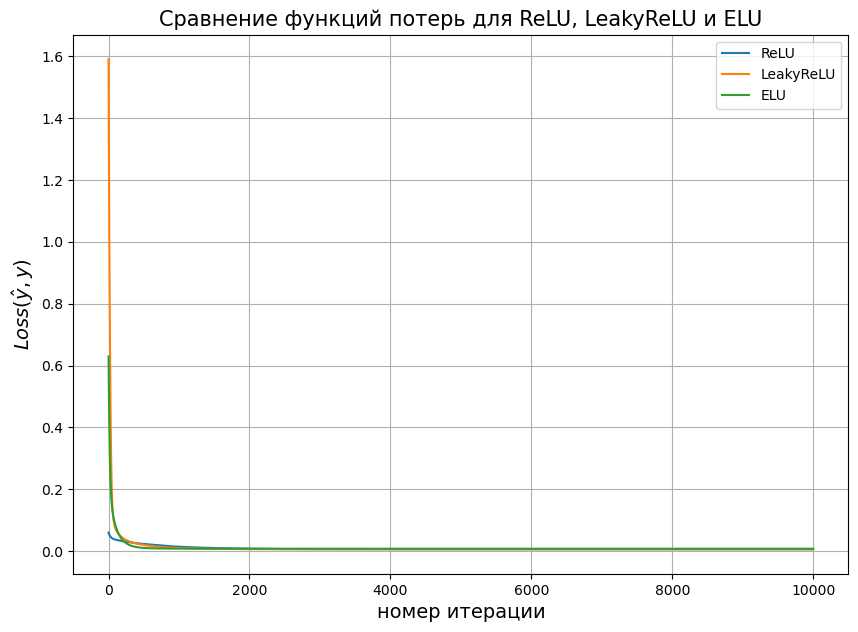

,activation,accuracy,final_loss
0,ReLU,1.0,0.006478
1,LeakyReLU,1.0,0.006478
2,ELU,1.0,0.008127


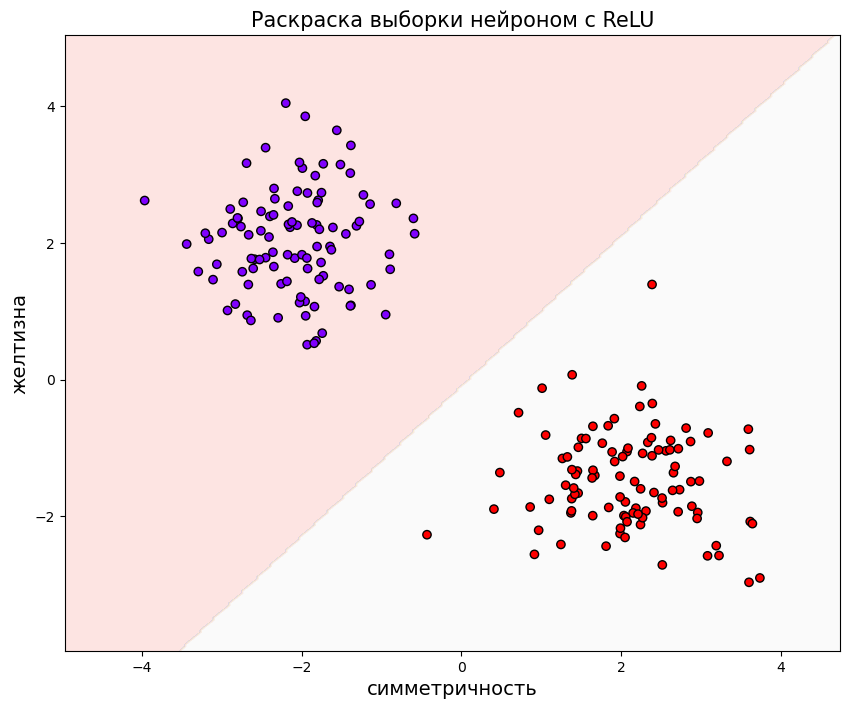

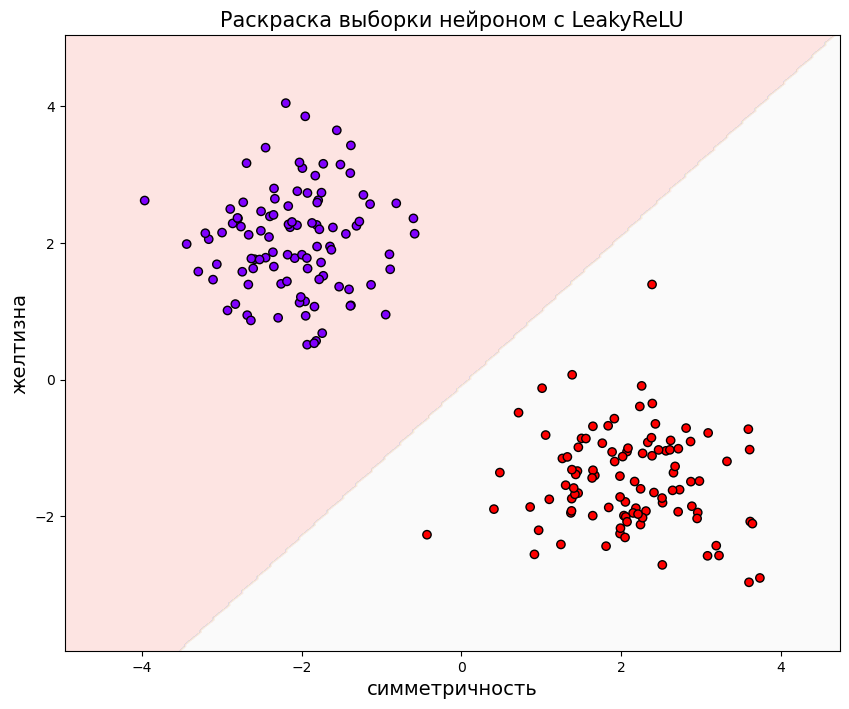

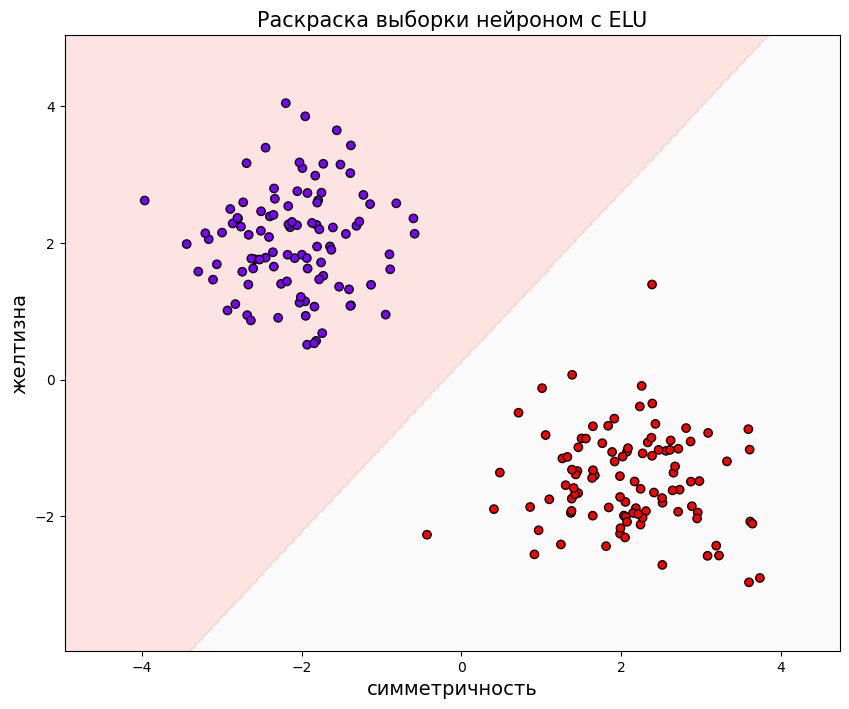

In [35]:
# Обучим нейроны с ReLU, LeakyReLU и ELU на одних и тех же данных
# и сравним Loss и accuracy.

from sklearn.metrics import accuracy_score

activation_models = {
    'ReLU': NeuronActivation(relu, relu_derivative, w=np.random.rand(X.shape[1], 1), b=np.random.rand(1)),
    'LeakyReLU': NeuronActivation(leaky_relu, leaky_relu_derivative, w=np.random.rand(X.shape[1], 1), b=np.random.rand(1)),
    'ELU': NeuronActivation(elu, elu_derivative, w=np.random.rand(X.shape[1], 1), b=np.random.rand(1)),
}

loss_history = {}
quality = []

for name, model in activation_models.items():
    loss_history[name] = model.fit(X, y, num_epochs=10000, learning_rate=0.005)
    y_pred_labels = (model.forward_pass(X) > 0.5).astype(int).ravel()
    quality.append({'activation': name, 'accuracy': accuracy_score(y.ravel(), y_pred_labels), 'final_loss': loss_history[name][-1]})

plt.figure(figsize=(10, 7))
for name, values in loss_history.items():
    plt.plot(values, label=name)
plt.title('Сравнение функций потерь для ReLU, LeakyReLU и ELU', fontsize=15)
plt.xlabel('номер итерации', fontsize=14)
plt.ylabel('$Loss(\\hat{y}, y)$', fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

quality_df = pd.DataFrame(quality).sort_values('accuracy', ascending=False)
display(quality_df)

# Покажем раскраску плоскости для каждой функции активации.
for name, model in activation_models.items():
    plot_neuron_decision_regions(model, X, y, f'Раскраска выборки нейроном с {name}')

## Задание 4. Сравнение собственной реализации с библиотечной

Сравните качество работы Вашего персептрона (с любой функцией активации) и алгоритма из библиотеки `sklearn` на датасете с сайта [Kaggle](https://www.kaggle.com) - [Gender Recognition by Voice](https://www.kaggle.com/primaryobjects/voicegender). (Код можно взять из файла Introducing_Scikit_Learn). Можно доработать собственную реализацию персептрона, сделав из него многослойный персептрон.

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


Размер датасета: (3168, 21)
Колонки: ['meanfreq', 'sd', 'median', 'Q25', 'Q75', 'IQR', 'skew', 'kurt', 'sp.ent', 'sfm', 'mode', 'centroid', 'meanfun', 'minfun', 'maxfun', 'meandom', 'mindom', 'maxdom', 'dfrange', 'modindx', 'label']
Кодировка классов: {'female': np.int64(0), 'male': np.int64(1)}


,model,accuracy,f1
0,Собственный нейрон LeakyReLU,0.974747,0.974811
1,sklearn MLPClassifier,0.977273,0.977500


Лучшие параметры sklearn MLPClassifier: {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (40,), 'mlp__learning_rate_init': 0.01}

Classification report для собственной реализации:
              precision    recall  f1-score   support

      female       0.98      0.97      0.97       396
        male       0.97      0.98      0.97       396

    accuracy                           0.97       792
   macro avg       0.97      0.97      0.97       792
weighted avg       0.97      0.97      0.97       792


Classification report для sklearn MLPClassifier:
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       396
        male       0.97      0.99      0.98       396

    accuracy                           0.98       792
   macro avg       0.98      0.98      0.98       792
weighted avg       0.98      0.98      0.98       792



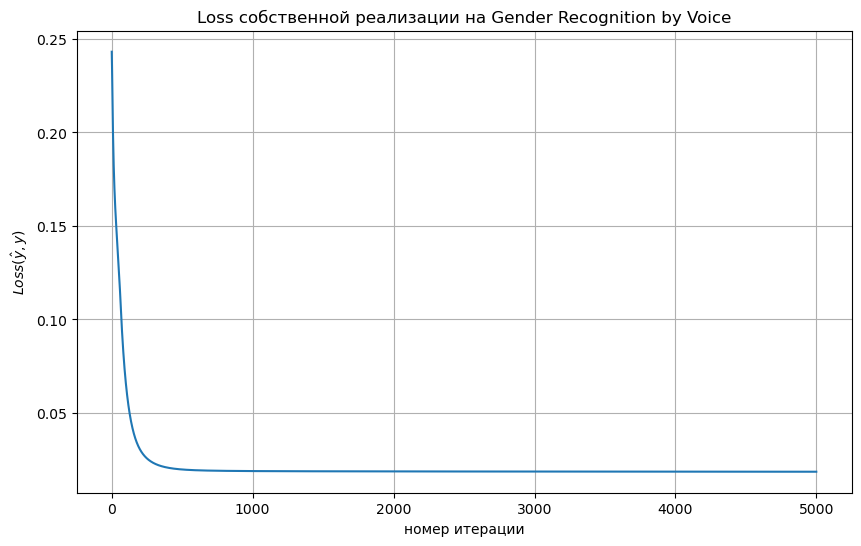

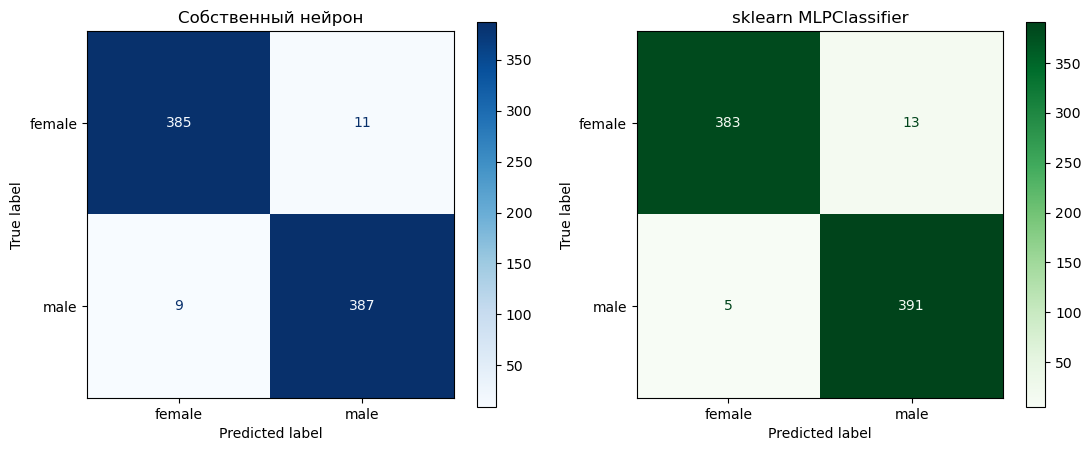

Вывод: библиотечный MLPClassifier показывает качество не ниже собственной реализации, так как это полноценный многослойный персептрон с подбором гиперпараметров.


In [36]:
# Задание 4. Сравнение собственной реализации с библиотечной на датасете Gender Recognition by Voice.
# Основной вариант: положите файл voice.csv в ./data/voice.csv.
# Если есть интернет, ноутбук попробует скачать официальный CSV из репозитория primaryobjects/voice-gender.

from pathlib import Path
from urllib.request import urlretrieve

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

voice_path = Path('./data/voice.csv')
voice_path.parent.mkdir(exist_ok=True)
voice_url = 'https://raw.githubusercontent.com/primaryobjects/voice-gender/master/voice.csv'

if not voice_path.exists():
    try:
        urlretrieve(voice_url, voice_path)
        print(f'Файл voice.csv скачан в {voice_path}')
    except Exception as exc:
        raise FileNotFoundError(
            'Не найден файл ./data/voice.csv и не удалось скачать его автоматически. '
            'Скачайте датасет Kaggle Gender Recognition by Voice и положите voice.csv в папку ./data.'
        ) from exc

voice = pd.read_csv(voice_path)
display(voice.head())
print('Размер датасета:', voice.shape)
print('Колонки:', list(voice.columns))

X_voice = voice.drop(columns=['label'])
y_voice_text = voice['label']

label_encoder = LabelEncoder()
y_voice = label_encoder.fit_transform(y_voice_text)  # female/male -> 0/1 или 1/0 в зависимости от сортировки LabelEncoder
print('Кодировка классов:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

X_voice_train, X_voice_test, y_voice_train, y_voice_test = train_test_split(
    X_voice,
    y_voice,
    test_size=0.25,
    random_state=RANDOM_SEED,
    stratify=y_voice,
)

# 1) Собственная реализация: один нейрон с LeakyReLU.
# Для корректной работы градиентного спуска масштабируем признаки.
voice_scaler = StandardScaler()
X_voice_train_scaled = voice_scaler.fit_transform(X_voice_train)
X_voice_test_scaled = voice_scaler.transform(X_voice_test)

custom_neuron = NeuronActivation(
    activation=leaky_relu,
    activation_derivative=leaky_relu_derivative,
    w=np.random.RandomState(RANDOM_SEED).normal(0, 0.01, size=(X_voice_train_scaled.shape[1], 1)),
    b=0,
)
custom_voice_loss = custom_neuron.fit(
    X_voice_train_scaled,
    y_voice_train.reshape(-1, 1),
    num_epochs=5000,
    learning_rate=0.01,
)
custom_voice_pred = (custom_neuron.forward_pass(X_voice_test_scaled) > 0.5).astype(int).ravel()

# 2) Библиотечная реализация sklearn: MLPClassifier + GridSearchCV.
sklearn_voice_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(max_iter=1000, random_state=RANDOM_SEED, early_stopping=True)),
    ]
)

voice_grid = {
    'mlp__hidden_layer_sizes': [(20,), (40,), (40, 20)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [0.0001, 0.001],
    'mlp__learning_rate_init': [0.001, 0.01],
}

sklearn_voice_search = GridSearchCV(
    sklearn_voice_pipeline,
    voice_grid,
    cv=3,
    scoring='f1',
    n_jobs=1,
)
sklearn_voice_search.fit(X_voice_train, y_voice_train)
sklearn_voice_pred = sklearn_voice_search.predict(X_voice_test)

comparison = pd.DataFrame(
    [
        {
            'model': 'Собственный нейрон LeakyReLU',
            'accuracy': accuracy_score(y_voice_test, custom_voice_pred),
            'f1': f1_score(y_voice_test, custom_voice_pred),
        },
        {
            'model': 'sklearn MLPClassifier',
            'accuracy': accuracy_score(y_voice_test, sklearn_voice_pred),
            'f1': f1_score(y_voice_test, sklearn_voice_pred),
        },
    ]
)
display(comparison)

print('Лучшие параметры sklearn MLPClassifier:', sklearn_voice_search.best_params_)
print('\nClassification report для собственной реализации:')
print(classification_report(y_voice_test, custom_voice_pred, target_names=label_encoder.classes_))
print('\nClassification report для sklearn MLPClassifier:')
print(classification_report(y_voice_test, sklearn_voice_pred, target_names=label_encoder.classes_))

plt.figure(figsize=(10, 6))
plt.plot(custom_voice_loss)
plt.title('Loss собственной реализации на Gender Recognition by Voice')
plt.xlabel('номер итерации')
plt.ylabel('$Loss(\\hat{y}, y)$')
plt.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_voice_test,
    custom_voice_pred,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Собственный нейрон')

ConfusionMatrixDisplay.from_predictions(
    y_voice_test,
    sklearn_voice_pred,
    display_labels=label_encoder.classes_,
    cmap='Greens',
    ax=axes[1],
)
axes[1].set_title('sklearn MLPClassifier')
plt.show()

# Вывод по заданию 4.
if comparison.loc[comparison['model'] == 'sklearn MLPClassifier', 'accuracy'].iloc[0] >= comparison.loc[comparison['model'] == 'Собственный нейрон LeakyReLU', 'accuracy'].iloc[0]:
    print('Вывод: библиотечный MLPClassifier показывает качество не ниже собственной реализации, так как это полноценный многослойный персептрон с подбором гиперпараметров.')
else:
    print('Вывод: на данном разбиении собственная реализация дала качество выше, но sklearn MLPClassifier остается более универсальной моделью за счет скрытых слоев и встроенной оптимизации.')

<h3 style="text-align: center;"><b>Полезные ссылки</b></h3>

0). Статья от Стэнфорда: http://cs231n.github.io/neural-networks-1/

1). Хорошая статья про функции активации: https://www.jeremyjordan.me/neural-networks-activation-functions/

2). [Видео от Siraj Raval](https://www.youtube.com/watch?v=-7scQpLossT7uo)

3). Современная статья про функции активации. Теперь на хайпе активация $swish(x) = x\sigma (\beta x)$: https://arxiv.org/pdf/1710.05941.pdf (кстати, при её поиске в некоторой степени использовался neural architecture search)

4). SeLU имеет очень интересные, доказанные с помощью теории вероятностей свойства: https://arxiv.org/pdf/1706.02515.pdf (да, в этой статье 102 страницы)

5). [Список функций активации из википедии](https://en.wikipedia.org/wiki/Activation_function)